In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df= pd.read_csv('netflix_movies (1).csv')

# data information

In [48]:
df.shape

(8807, 12)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [50]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [51]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [52]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Preprocessing

## 1. Handling Missing Values

In [53]:
# Fill missing ratings with the most frequent rating
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [54]:
# Fill missing duration with the most frequent duration (only 3 missing)
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

In [55]:
# For director, cast, and country, we will fill with 'Unknown' as these are categorical and many are missing
df['director']= df['director'].fillna('Unknown')
df['cast']= df['cast'].fillna('Unknown')
df['country']= df['country'].fillna('Unknown')

In [56]:
# Drop rows where 'date_added' is missing (only 10 rows)
df.dropna(subset=['date_added'] , inplace=True)

In [57]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

## 2. Data Cleaning & Formatting

In [58]:
# Clean date_added and convert to datetime
df['date_added']= df['date_added'].str.strip()
df['date_added']= pd.to_datetime(df['date_added'], errors='coerce')

In [59]:
# Drop any rows that failed date conversion
df.dropna(subset=['date_added'], inplace=True)

In [60]:
df.shape

(8797, 12)

## 3. Standardizing Text Data

In [61]:
df['type'] = df['type'].str.strip()
df['title'] = df['title'].str.strip()

In [62]:
df.type

0         Movie
1       TV Show
2       TV Show
3       TV Show
4       TV Show
         ...   
8802      Movie
8803    TV Show
8804      Movie
8805      Movie
8806      Movie
Name: type, Length: 8797, dtype: object

In [63]:
df.title

0        Dick Johnson Is Dead
1               Blood & Water
2                   Ganglands
3       Jailbirds New Orleans
4                Kota Factory
                ...          
8802                   Zodiac
8803              Zombie Dumb
8804               Zombieland
8805                     Zoom
8806                   Zubaan
Name: title, Length: 8797, dtype: object

In [64]:
df.to_csv('netflix_movies_cleaned.csv', index=False)

# Exploratory Data Analysis (EDA)

In [65]:
df = pd.read_csv('netflix_movies_cleaned.csv')

In [66]:
sns.set(style='whitegrid')

## 1. Distribution of Content Types

In [67]:
# 1. Content Distribution (%)
type_dist = df['type'].value_counts(normalize=True) * 100
type_dist

type
Movie      69.694214
TV Show    30.305786
Name: proportion, dtype: float64

In [68]:
type_counts = df['type'].value_counts()
print(type_counts)

type
Movie      6131
TV Show    2666
Name: count, dtype: int64


C:\Users\SHAHD\AppData\Local\Temp\ipykernel_3540\2517471869.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df , x='type' , palette='viridis' )


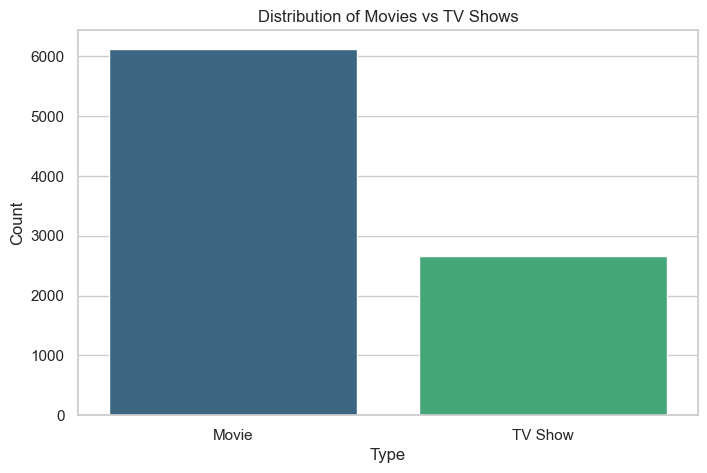

In [69]:
plt.figure(figsize=(8,5))
sns.countplot(data=df , x='type' , palette='viridis' )
plt.title('Distribution of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

## 2. Top 10 Countries with Most Content

In [70]:
top_coun= df['country'].value_counts().head(10)
print(top_coun)

country
United States     2812
India              972
Unknown            830
United Kingdom     418
Japan              244
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64


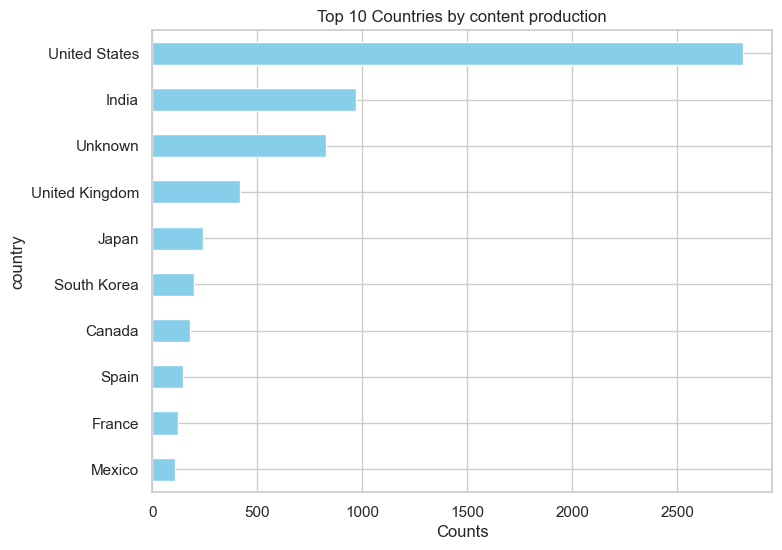

In [71]:
plt.figure(figsize=(8,6))
top_coun.plot(kind='barh', color= 'skyblue')
plt.title('Top 10 Countries by content production')
plt.gca().invert_yaxis()
plt.xlabel('Counts')
plt.show()

## 3. Content Added Over Time

In [72]:
# 7. Recent Production Volume (Last 5 Years)
recent_production = df['release_year'].value_counts().sort_index(ascending=False).head(5)
recent_production

release_year
2021     592
2020     953
2019    1030
2018    1146
2017    1032
Name: count, dtype: int64

In [73]:
df['year_added'] = pd.to_datetime(df['date_added']).dt.year
growth = df['year_added'].value_counts().sort_index()

In [74]:
growth

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

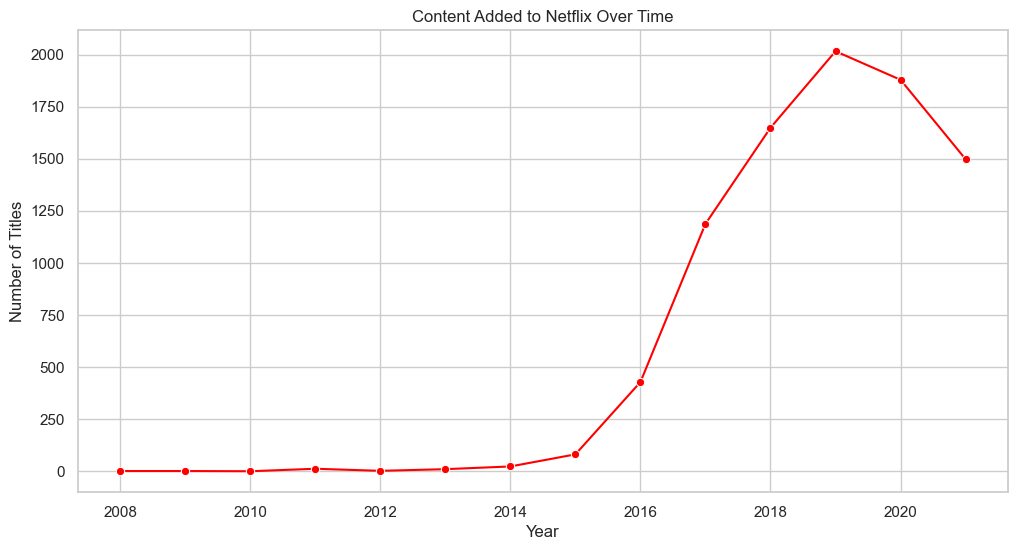

In [75]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=growth.index, y=growth.values, marker='o', color='red')
plt.title('Content Added to Netflix Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show()

## 4. Distribution of Ratings

In [76]:
ratings_order = df['rating'].value_counts().index
print(ratings_order)

Index(['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y7', 'TV-Y', 'PG', 'TV-G',
       'NR', 'G', 'TV-Y7-FV', 'NC-17', 'UR', '74 min', '84 min', '66 min'],
      dtype='object', name='rating')


C:\Users\SHAHD\AppData\Local\Temp\ipykernel_3540\4287006782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=ratings_order, palette='magma')


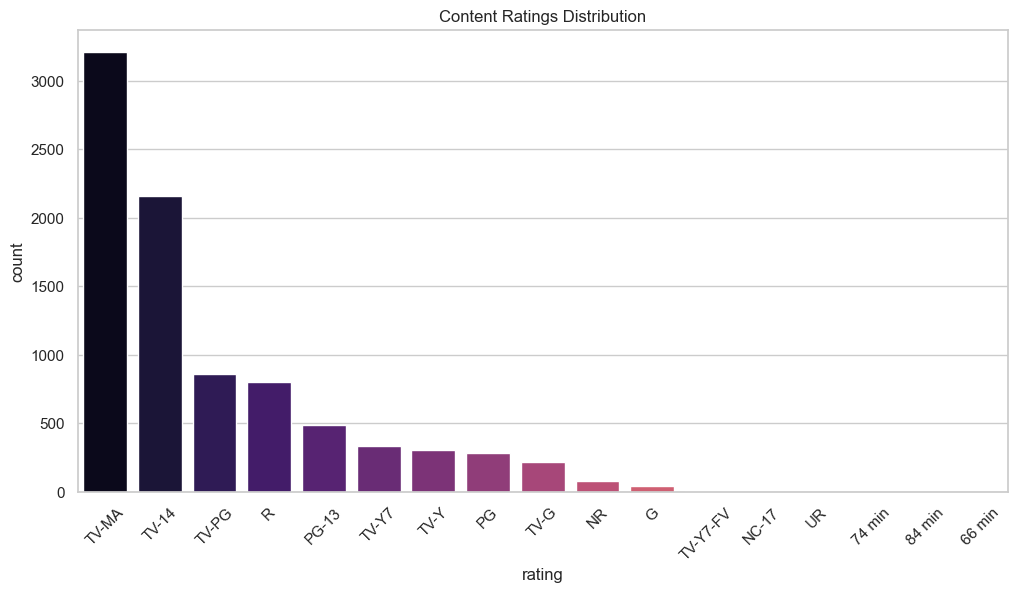

In [77]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='rating', order=ratings_order, palette='magma')
plt.title('Content Ratings Distribution')
plt.xticks(rotation=45)
plt.show()

## 5. Release Year Trend

In [78]:
movies_df = df[df['type'] == 'Movie'].copy()
tv_df = df[df['type'] == 'TV Show'].copy()

In [79]:
# 8. Avg Release Year Comparison
avg_movie_release = movies_df['release_year'].mean()
avg_tv_release = tv_df['release_year'].mean()
print(avg_tv_release)

2016.6256564141036


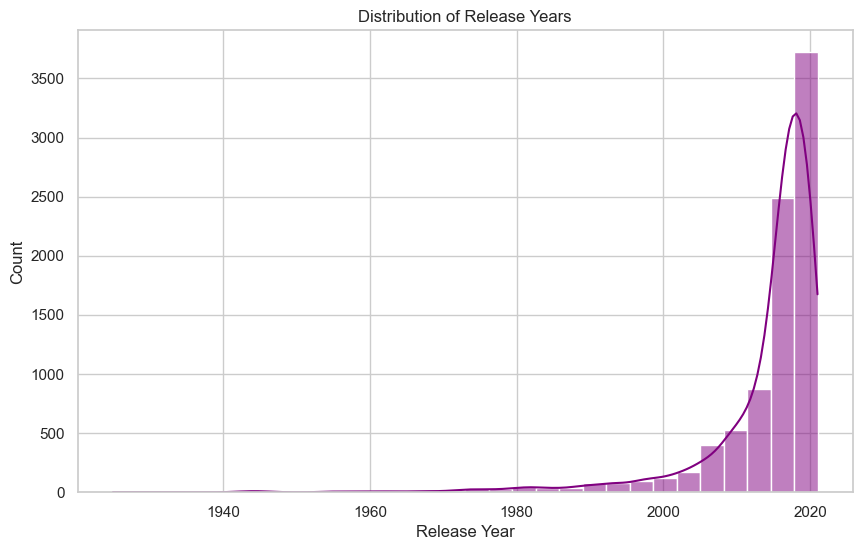

In [80]:
plt.figure(figsize=(10, 6))
sns.histplot(df['release_year'], bins=30, kde=True, color='purple')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.show()

## 6. Top 5 Genres

In [81]:
# 2. Top 5 Genres
all_genres = df['listed_in'].str.split(', ').explode()
top_genres = all_genres.value_counts().head(5)
top_genres

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1350
Documentaries              869
Name: count, dtype: int64

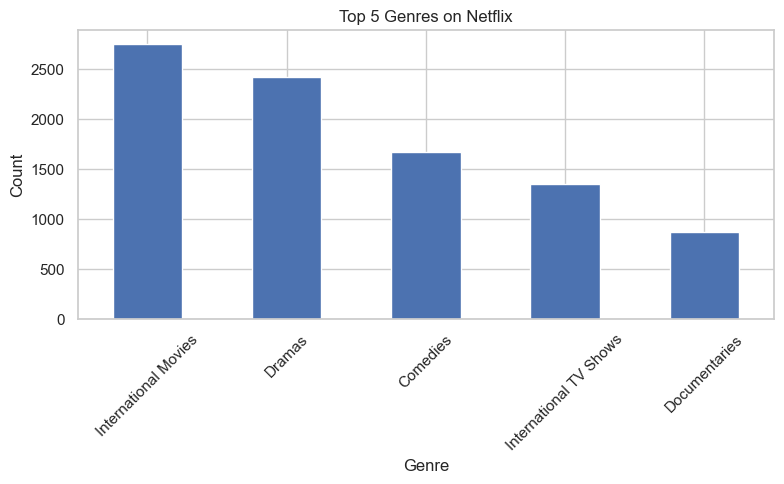

In [82]:
plt.figure(figsize=(8,5))
top_genres.plot(kind='bar')

plt.title('Top 5 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## more

In [83]:
# 3. Top Directors (Excluding 'Unknown')
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(5)
top_directors

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Name: count, dtype: int64

In [84]:
# 6. TV Shows with most seasons
tv_df = df[df['type'] == 'TV Show'].copy()
tv_df['seasons'] = tv_df['duration'].str.extract('(\d+)').astype(float)
top_tv_seasons = tv_df[['title', 'seasons']].sort_values(by='seasons', ascending=False).head(10)
top_tv_seasons

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\SHAHD\AppData\Local\Temp\ipykernel_3540\3722002198.py:3: SyntaxWarning: invalid escape sequence '\d'
  tv_df['seasons'] = tv_df['duration'].str.extract('(\d+)').astype(float)


,title,seasons
548,Grey's Anatomy,17.0
2423,Supernatural,15.0
4798,NCIS,15.0
4220,COMEDIANS of the world,13.0
1354,Heartland,13.0
4964,Trailer Park Boys,12.0
5412,Criminal Minds,12.0
6454,Cheers,11.0
1622,Stargate SG-1,10.0
2203,Shameless (U.S.),10.0
